# **NER with BERT**

## **SETUP**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install --upgrade transformers -qq
pip install datasets -qq
!pip install transformers datasets seqeval -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 110.4 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import BertTokenizerFast
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from seqeval.metrics import classification_report

## **DATA PREPARATION**

We load an IOB-formatted file where each line contains a token and its corresponding label (e.g., B-NOME, I-NOME, or O). Sentences are separated by empty lines.
For example:
```
Ciao O  
sono O  
Mario B-NOME  

Ho O  
trent'anni B-ETA
```
is processed into:
```
[["Ciao", "sono", "Mario"], ["Ho", "trent'anni"]]
[["O", "O", "B-NOME"], ["O", "B-ETA"]]
```


In [ ]:
# === 1. Load and preprocess the IOB file ===
def read_iob_file(filepath):
    sentences = []
    labels = []
    with open(filepath, encoding="utf-8") as f:
        tokens, tags = [], []
        for line in f:
            line = line.strip()
            if not line:
                if tokens:
                    sentences.append(tokens)
                    labels.append(tags)
                    tokens, tags = [], []
                continue
            parts = line.split()
            if len(parts) != 2:
                continue  # skip malformed lines, e.g. non-binary.
            token, tag = parts
            tokens.append(token)
            tags.append(tag)
        if tokens:  # add the last sentence
            sentences.append(tokens)
            labels.append(tags)
    return sentences, labels


file_path = "/content/drive/MyDrive/pp/frasi_gemini.txt"
sentences, tags = read_iob_file(file_path)

In [ ]:
print(tags)

[['O', 'O', 'O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'B-CITTA', 'O'], ['O', 'O', 'B-NOME', 'O', 'O', 'O', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'B-ALTEZZA', 'I-ALTEZZA'], ['O', 'O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-CITTA', 'O', 'O', 'O', 'B-HOBBY', 'O'], ['O', 'O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'O', 'B-PROFESSIONE', 'O', 'O', 'B-PERS', 'I-PERS', 'I-PERS'], ['O', 'O', 'O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-RANGEETA', 'I-RANGEETA', 'I-RANGEETA', 'I-RANGEETA', 'I-RANGEETA', 'I-RANGEETA', 'O'], ['O', 'B-NOME', 'O', 'O', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'O', 'B-HOBBY', 'I-HOBBY', 'I-HOBBY', 'O'], ['O', 'O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'B-INTERESSE', 'I-INTERESSE', 'I-INTERESSE', 'I-INTERESSE', 'I-INTERESSE'], ['O', 'O', 'B-NOME', 'O', 'O', 'B-ETA', 'O', 'O', 'O', 'O', 'B-PROFESSIONE', 'O', 'O', 'O', 'O', 'O', 'O', 'B-HOBBY', 'O'], ['O', 'O', 'O', 'O', 'B-NOME', 'O',

Creating mappings between IOB tags and unique IDs for model compatibility and easier label handling.

In [ ]:
tag2id = {tag: id for id, tag in enumerate(sorted(list(set([item for sublist in tags for item in sublist]))))}
id2tag = {id: tag for tag, id in tag2id.items()}

print("Tag to ID mapping:")
print(tag2id)
print("\nID to Tag mapping:")
id2tag

Tag to ID mapping:
{'B-ALTEZZA': 0, 'B-CITTA': 1, 'B-CITTA.': 2, 'B-ETA': 3, 'B-GENERE': 4, 'B-HOBBY': 5, 'B-HOBBY.': 6, 'B-INTERESSE': 7, 'B-NOME': 8, 'B-NOME,': 9, 'B-NOME.': 10, 'B-PERS': 11, 'B-PERS.': 12, 'B-PROFESSIONE': 13, 'B-PROFESSIONE.': 14, 'B-RANGEETA': 15, 'I-ALTEZZA': 16, 'I-CITTA': 17, 'I-GENERE': 18, 'I-HOBBY': 19, 'I-INTERESSE': 20, 'I-PERS': 21, 'I-PERS.': 22, 'I-PROFESSIONE': 23, 'I-RANGEETA': 24, 'O': 25, 'O.': 26, 'TAG': 27}

ID to Tag mapping:


{0: 'B-ALTEZZA',
 1: 'B-CITTA',
 2: 'B-CITTA.',
 3: 'B-ETA',
 4: 'B-GENERE',
 5: 'B-HOBBY',
 6: 'B-HOBBY.',
 7: 'B-INTERESSE',
 8: 'B-NOME',
 9: 'B-NOME,',
 10: 'B-NOME.',
 11: 'B-PERS',
 12: 'B-PERS.',
 13: 'B-PROFESSIONE',
 14: 'B-PROFESSIONE.',
 15: 'B-RANGEETA',
 16: 'I-ALTEZZA',
 17: 'I-CITTA',
 18: 'I-GENERE',
 19: 'I-HOBBY',
 20: 'I-INTERESSE',
 21: 'I-PERS',
 22: 'I-PERS.',
 23: 'I-PROFESSIONE',
 24: 'I-RANGEETA',
 25: 'O',
 26: 'O.',
 27: 'TAG'}

In [ ]:
'''
#### TEST
# 1. Clean tags from unwanted punctuation and spaces
tags_puliti = [item.strip(' .,') for sublist in tags for item in sublist]

# 2. Create mappings using the cleaned list
tag2id = {tag: id for id, tag in enumerate(sorted(list(set(tags_puliti))))}
id2tag = {id: tag for tag, id in tag2id.items()}

print("Tag to ID mapping:")
print(tag2id)
print("\nID to Tag mapping:")
id2tag
'''

Tag to ID mapping:
{'B-ALTEZZA': 0, 'B-CITTA': 1, 'B-ETA': 2, 'B-GENERE': 3, 'B-HOBBY': 4, 'B-INTERESSE': 5, 'B-NOME': 6, 'B-PERS': 7, 'B-PROFESSIONE': 8, 'B-RANGEETA': 9, 'I-ALTEZZA': 10, 'I-CITTA': 11, 'I-GENERE': 12, 'I-HOBBY': 13, 'I-INTERESSE': 14, 'I-PERS': 15, 'I-PROFESSIONE': 16, 'I-RANGEETA': 17, 'O': 18, 'TAG': 19}

ID to Tag mapping:


{0: 'B-ALTEZZA',
 1: 'B-CITTA',
 2: 'B-ETA',
 3: 'B-GENERE',
 4: 'B-HOBBY',
 5: 'B-INTERESSE',
 6: 'B-NOME',
 7: 'B-PERS',
 8: 'B-PROFESSIONE',
 9: 'B-RANGEETA',
 10: 'I-ALTEZZA',
 11: 'I-CITTA',
 12: 'I-GENERE',
 13: 'I-HOBBY',
 14: 'I-INTERESSE',
 15: 'I-PERS',
 16: 'I-PROFESSIONE',
 17: 'I-RANGEETA',
 18: 'O',
 19: 'TAG'}

In [ ]:
unique_tags = list(sorted(set(tag for doc in tags for tag in doc)))
tag2id = {tag: i for i, tag in enumerate(unique_tags)}
id2tag = {i: tag for tag, i in tag2id.items()}

In [ ]:
tag2id

{'B-ALTEZZA': 0,
 'B-CITTA': 1,
 'B-CITTA.': 2,
 'B-ETA': 3,
 'B-GENERE': 4,
 'B-HOBBY': 5,
 'B-HOBBY.': 6,
 'B-INTERESSE': 7,
 'B-NOME': 8,
 'B-NOME,': 9,
 'B-NOME.': 10,
 'B-PERS': 11,
 'B-PERS.': 12,
 'B-PROFESSIONE': 13,
 'B-PROFESSIONE.': 14,
 'B-RANGEETA': 15,
 'I-ALTEZZA': 16,
 'I-CITTA': 17,
 'I-GENERE': 18,
 'I-HOBBY': 19,
 'I-INTERESSE': 20,
 'I-PERS': 21,
 'I-PERS.': 22,
 'I-PROFESSIONE': 23,
 'I-RANGEETA': 24,
 'O': 25,
 'O.': 26,
 'TAG': 27}

## **DATA EXPLORATION**

Visualizing the distribution of IOB tags across all sentences to understand label frequency in the dataset.

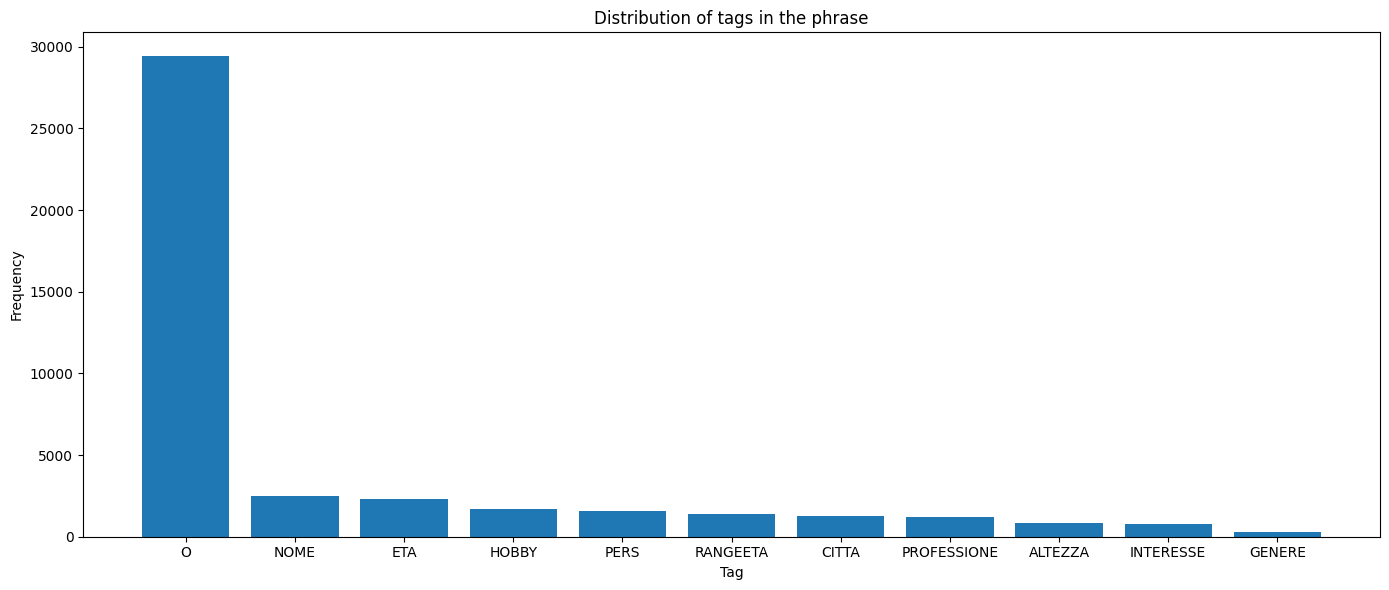

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt

to_exclude = {"NER", "TAG"}  # remove any labels to hide here

def clean_label(t: str) -> str:
    t = str(t).strip()
    t = re.sub(r'[\s\.\,\;\:]+$', '', t)   # remove trailing spaces/punctuation
    t = re.sub(r'\s*-\s*', '-', t)         # normalize the hyphen
    return t

def base(t: str) -> str:
    return t if t == "O" else t.split("-", 1)[-1]  # aggregate B-/I-

# 1) clean  2) aggregate  3) filter
flat = [clean_label(t) for seq in tags for t in seq]
agg  = [base(t) for t in flat]
agg  = [t for t in agg if t not in to_exclude]

counts = Counter(agg)
items  = sorted(counts.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, _ in items]
vals   = [v for _, v in items]

plt.figure(figsize=(14, 6))
plt.bar(labels, vals)
plt.xlabel("Tag")
plt.ylabel("Frequency")
plt.title("Distribution of Tags in the Phrases")
plt.tight_layout()
plt.savefig("/content/tag_distribution.jpg", dpi=600, bbox_inches="tight")
plt.show()


Displaying the 20 most frequent words in the dataset (case-insensitive) to explore common vocabulary.

In [ ]:
all_words = [word.lower() for sentence_words in sentences for word in sentence_words] # Convert to lowercase for case-insensitive counting

word_counts = Counter(all_words)

top_20_words = word_counts.most_common(20)

print("The 20 most frequent words")
for word, count in top_20_words:
    print(f"{word}: {count}")


The 20 most frequent words
sono: 3579
e: 3487
mi: 1887
,: 1738
anni: 1687
ho: 1652
di: 1395
.: 1147
una: 1016
un: 921
chiamo: 745
i: 706
a: 564
cerco: 554
anni.: 506
persona: 503
25: 455
piace: 445
35: 425
come: 414


Plotting the top 50 most frequent words in the dataset to visualize vocabulary distribution.

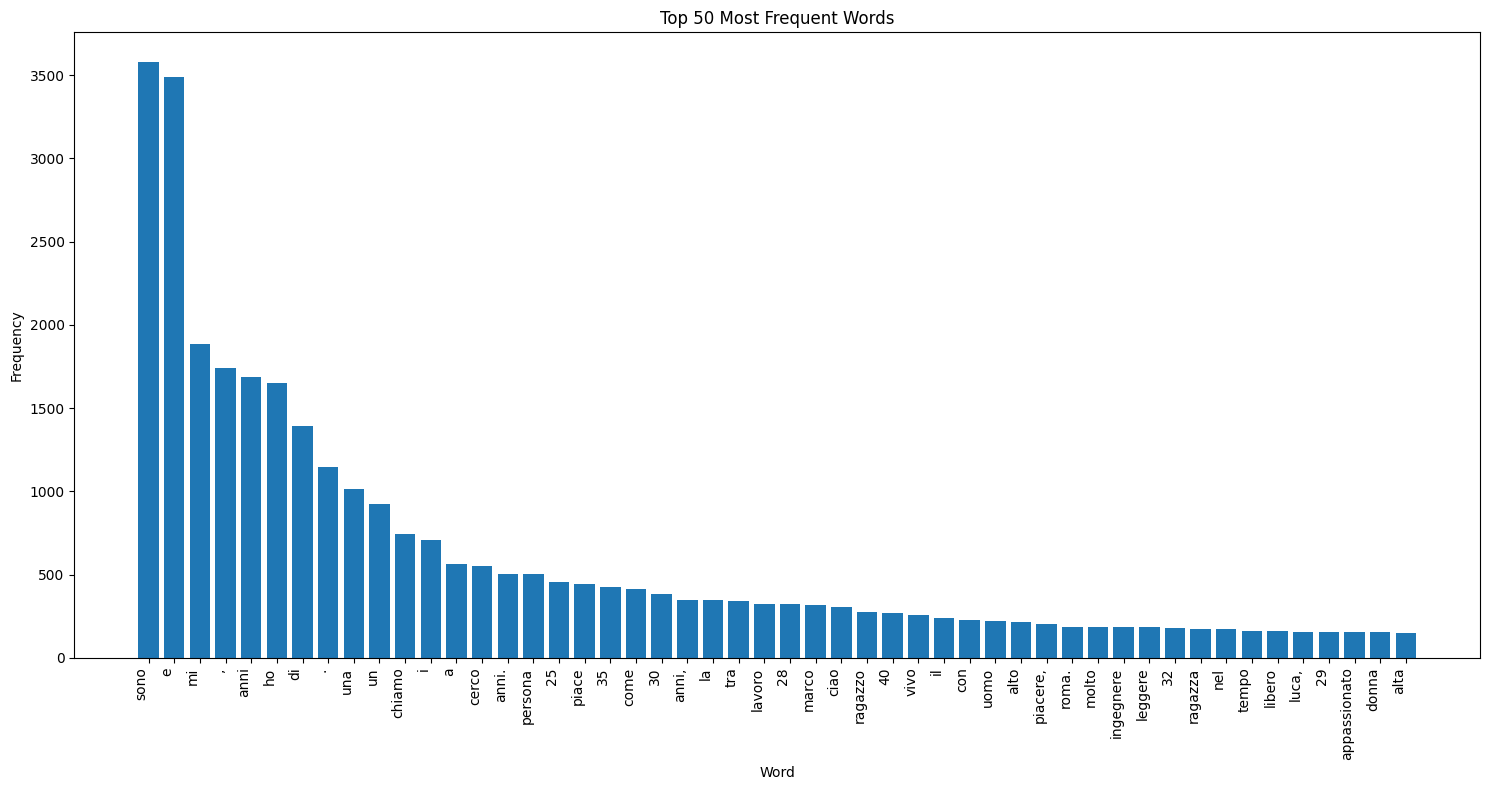

In [ ]:
import matplotlib.pyplot as plt

top_50_words = word_counts.most_common(50)

word_names_50 = [word for word, count in top_50_words]
word_frequencies_50 = [count for word, count in top_50_words]

plt.figure(figsize=(15, 8))
plt.bar(word_names_50, word_frequencies_50)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 50 Most Frequent Words")
plt.xticks(rotation=90, ha="right") # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## **MODEL PREPARATION FOR TOKEN CLASSIFICATION**

### TOKENIZER AND LABEL ALIGNEMENT

Tokenizing sentences and aligning IOB labels with BERT sub-tokens for proper input formatting.

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained("dbmdz/bert-base-italian-cased", num_labels=len(tag2id))

def tokenize_and_align(sentences, labels):
    tokenized_inputs = tokenizer(sentences, truncation=True, is_split_into_words=True, padding=True)  # truncation=True tronca frasi troppo lunghe  /  is_split_into_words=True indica che l’input è già suddiviso in parole (token).  /  padding=True aggiunge padding per rendere tutte le sequenze della stessa lunghezza
    aligned_labels = []
    for i, label in enumerate(labels):
        word_ids = tokenized_inputs.word_ids(batch_index=i) # For each token, we get the corresponding original word it belongs to (or None if it is a special token like [CLS]).
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)  # Ignore --> If the token is not associated with any word (special token), we assign -100 which tells the model to ignore that token in the loss computation.
            elif word_idx != previous_word_idx:
                label_ids.append(tag2id[label[word_idx]])
            else:
                label_ids.append(tag2id[label[word_idx]])  # same token = same label
            previous_word_idx = word_idx
        aligned_labels.append(label_ids)
    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

### TRAIN/VALIDATION SPLIT & DATASET CREATION

Splitting data into training and validation sets, then tokenizing and aligning labels to create datasets ready for model training.

In [ ]:
train_sentences, val_sentences, train_tags, val_tags = train_test_split(sentences, tags, test_size=0.2, random_state=42)

train_dataset = Dataset.from_dict(tokenize_and_align(train_sentences, train_tags))
val_dataset = Dataset.from_dict(tokenize_and_align(val_sentences, val_tags))

In [ ]:
train_df = train_dataset.to_pandas()

train_df.head()

,input_ids,token_type_ids,attention_mask,labels
0,"[102, 481, 6458, 16504, 1307, 480, 5008, 578, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...","[-100, 25, 25, 8, 25, 25, 3, 25, 25, 25, 25, 4..."
1,"[102, 694, 6898, 1307, 480, 1964, 578, 126, 21...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[-100, 25, 8, 8, 25, 3, 25, 25, 25, 13, 13, -1..."
2,"[102, 694, 6898, 1307, 480, 4076, 578, 126, 15...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 25, 8, 8, 25, 3, 25, 25, 25, 25, 7, 25,..."
3,"[102, 12079, 1307, 288, 6141, 1307, 141, 2627,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 25, 25, 25, 8, 25, 25, 25, 25, 3, 25, 0..."
4,"[102, 17467, 141, 2627, 293, 134, 1591, 126, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ...","[-100, 25, 25, 7, 25, 25, 15, 24, 24, 24, 25, ..."


Loading a pre-trained BERT model for token classification with the specified number of label classes.

In [ ]:
from transformers import BertForTokenClassification
model = BertForTokenClassification.from_pretrained("dbmdz/bert-base-italian-cased", num_labels=len(tag2id))

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dbmdz/bert-base-italian-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Setting up training parameters and strategies for fine-tuning the BERT token classification model.

## **FINE-TUNING THE BERT MODEL**

### TRAINING ARGUMENTS

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./ner_bert",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1", # Changed to eval_f1 as it is calculated in compute_metrics
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_strategy = "epoch",
    report_to="none",
)

### METRICS FUNCTION

Defining a custom metric function to compute the weighted F1 score by comparing true and predicted labels, ignoring special tokens.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    true_labels = [[id2tag[l] for l in label if l != -100] for label in labels]
    pred_labels = [[id2tag[p] for p, l in zip(pred, label) if l != -100] for pred, label in zip(predictions, labels)]
    report = classification_report(true_labels, pred_labels, output_dict=True)
    return {"f1": report["weighted avg"]["f1-score"]}

### TRAINER INITIALIZATION AND TRAINING

Initializing the Trainer with model, data, and settings, then starting the fine-tuning process on the token classification task.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-4027472573.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1
1,0.213300,0.320184,0.788635
2,0.172300,0.353518,0.794737
3,0.155200,0.342879,0.794836
4,0.181900,0.348862,0.797508
5,0.166900,0.349175,0.803076


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: TAG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: TAG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/

TrainOutput(global_step=1430, training_loss=0.17790783702076732, metrics={'train_runtime': 516.1664, 'train_samples_per_second': 22.125, 'train_steps_per_second': 2.77, 'total_flos': 1288322260873440.0, 'train_loss': 0.17790783702076732, 'epoch': 5.0})

In [ ]:
results = trainer.evaluate()
print("Final Average F1:", results["eval_f1"])

Average F1 finale: 0.8030761532446521


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: TAG seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Copy the model folder to Drive
!cp -r ./ner_bert /content/drive/MyDrive/

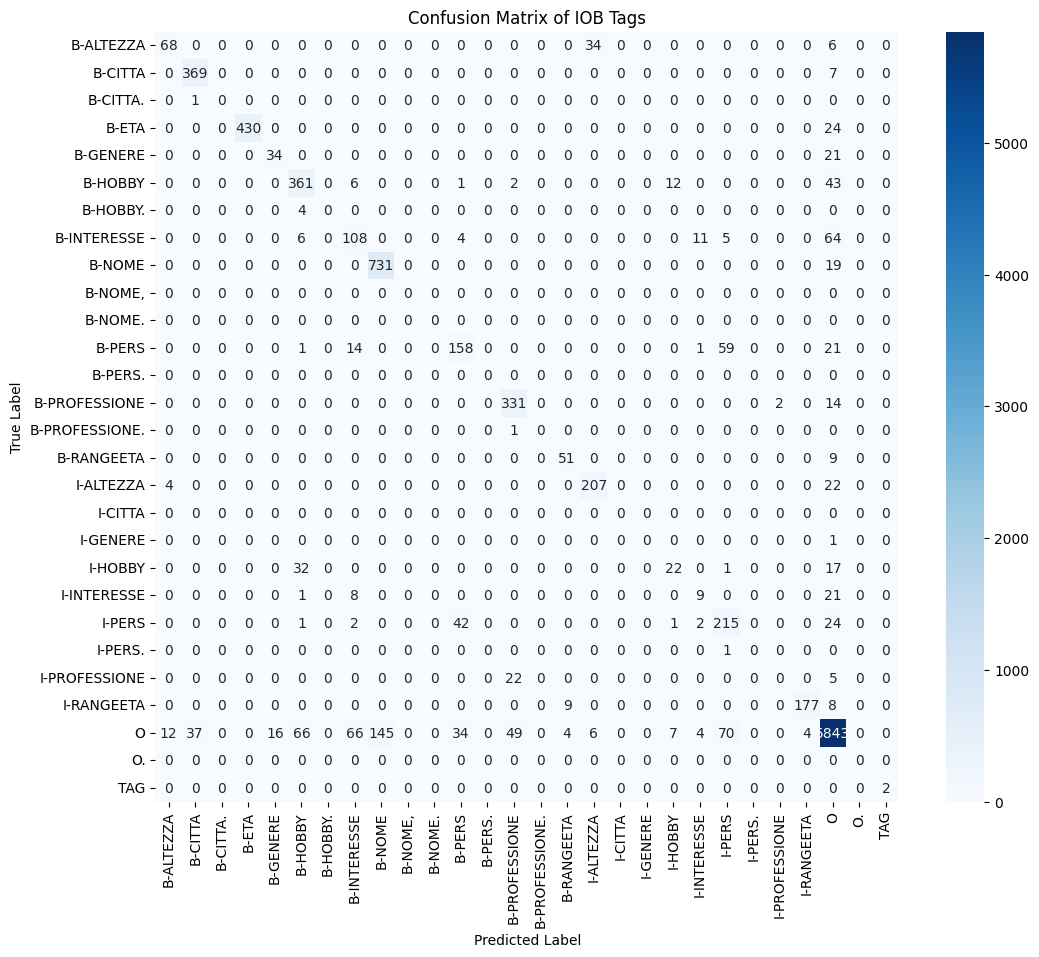

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Get predictions
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Align only where label != -100
true_tags, pred_tags = [], []
for true_seq, pred_seq in zip(y_true, y_pred):
    for t, p in zip(true_seq, pred_seq):
        if t != -100:
            true_tags.append(id2tag[t])
            pred_tags.append(id2tag[p])

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

cm = confusion_matrix(true_tags, pred_tags, labels=unique_tags)
df_cm = pd.DataFrame(cm, index=unique_tags, columns=unique_tags)

plt.figure(figsize=(12, 10))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix of IOB Tags")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [ ]:
import re
from transformers import pipeline

# Create a Named Entity Recognition (NER) pipeline
nlp = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Original sentence
frase = "Buongiorno, sono Pietro ho 21 anni, sono un uomo e sono di Verona. Faccio lo studente e sono molto riflessivo e abbastanza estroverso. Sono altro un metro e 88 e cerco una donna tra i 18 e i 24 anni."


# Remove punctuation (keep only letters, numbers, and spaces)
frase_pulita = re.sub(r"[^\w\sàèéìòù']", '', frase)

# Run inference
risultati = nlp(frase_pulita)

# Map numeric labels to original tags
for risultato in risultati:
    risultato['entity_group'] = id2tag[int(risultato['entity_group'].replace('LABEL_', ''))]

# Display results with the correct labels
print(risultati)



Device set to use cuda:0


[{'entity_group': 'O', 'score': np.float32(0.99629676), 'word': 'Buongiorno sono', 'start': 0, 'end': 15}, {'entity_group': 'B-NOME', 'score': np.float32(0.9960373), 'word': 'Pietro', 'start': 16, 'end': 22}, {'entity_group': 'O', 'score': np.float32(0.93797964), 'word': 'ho', 'start': 23, 'end': 25}, {'entity_group': 'B-ETA', 'score': np.float32(0.99885535), 'word': '21', 'start': 26, 'end': 28}, {'entity_group': 'O', 'score': np.float32(0.9921511), 'word': 'anni sono un', 'start': 29, 'end': 41}, {'entity_group': 'B-GENERE', 'score': np.float32(0.524834), 'word': 'uomo', 'start': 42, 'end': 46}, {'entity_group': 'O', 'score': np.float32(0.99700576), 'word': 'e sono di', 'start': 47, 'end': 56}, {'entity_group': 'B-CITTA', 'score': np.float32(0.9940996), 'word': 'Verona', 'start': 57, 'end': 63}, {'entity_group': 'O', 'score': np.float32(0.98637706), 'word': 'Faccio lo', 'start': 64, 'end': 73}, {'entity_group': 'B-PROFESSIONE', 'score': np.float32(0.98074496), 'word': 'studente', 'st

In [ ]:
# Run inference
risultati = nlp(frase_pulita)

# If the model returns labels like "LABEL_1", convert them with id2tag (optional)
for r in risultati:
    if r['entity_group'].startswith("LABEL_") and id2tag:
        r['entity_group'] = id2tag[int(r['entity_group'].replace('LABEL_', ''))]

# Print the results as a list
print("Entità riconosciute:\n")
for r in risultati:
    parola = r["word"].strip()
    entita = r["entity_group"]
    print(f"- {parola} -> {entita}")


Entità riconosciute:

- Buongiorno sono -> O
- Pietro -> B-NOME
- ho -> O
- 21 -> B-ETA
- anni sono un -> O
- uomo -> B-GENERE
- e sono di -> O
- Verona -> B-CITTA
- Faccio lo -> O
- studente -> B-PROFESSIONE
- e sono molto -> O
- riflessivo -> B-PERS
- e -> O
- abbastanza estro -> I-PERS
- ##verso -> B-PERS
- Sono altro -> O
- un -> B-ALTEZZA
- metro e 88 -> I-ALTEZZA
- e cerco una -> O
- donna -> B-INTERESSE
- tra i -> O
- 18 -> B-RANGEETA
- e i 24 -> I-RANGEETA
- anni -> O


In [ ]:
import re
from transformers import pipeline

# Create a Named Entity Recognition (NER) pipeline
nlp = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Original sentence
frase = "Ciao, sono Pietro ho 21 anni, sono un uomo e sono di Milano. Mi piace pescare"


# Remove punctuation (keep only letters, numbers, and spaces)
frase_pulita = re.sub(r"[^\w\sàèéìòù']", '', frase)

# Run inference
risultati = nlp(frase_pulita)

# Map numeric labels to original tags
for risultato in risultati:
    risultato['entity_group'] = id2tag[int(risultato['entity_group'].replace('LABEL_', ''))]

# Display results with the correct labels
print(risultati)



Device set to use cuda:0


[{'entity_group': 'O', 'score': np.float32(0.99799895), 'word': 'Ciao sono', 'start': 0, 'end': 9}, {'entity_group': 'B-NOME', 'score': np.float32(0.99273574), 'word': 'Pietro', 'start': 10, 'end': 16}, {'entity_group': 'O', 'score': np.float32(0.97171766), 'word': 'ho', 'start': 17, 'end': 19}, {'entity_group': 'B-ETA', 'score': np.float32(0.99629223), 'word': '21', 'start': 20, 'end': 22}, {'entity_group': 'O', 'score': np.float32(0.9892049), 'word': 'anni sono un', 'start': 23, 'end': 35}, {'entity_group': 'B-GENERE', 'score': np.float32(0.7780635), 'word': 'uomo', 'start': 36, 'end': 40}, {'entity_group': 'O', 'score': np.float32(0.9944952), 'word': 'e sono di', 'start': 41, 'end': 50}, {'entity_group': 'B-CITTA', 'score': np.float32(0.99176157), 'word': 'Milano', 'start': 51, 'end': 57}, {'entity_group': 'O', 'score': np.float32(0.9586972), 'word': 'Mi piace', 'start': 58, 'end': 66}, {'entity_group': 'B-HOBBY', 'score': np.float32(0.91813326), 'word': 'pescare', 'start': 67, 'end

In [ ]:
# Run inference
risultati = nlp(frase_pulita)

# If the model returns labels like "LABEL_1", convert them with id2tag (optional)
for r in risultati:
    if r['entity_group'].startswith("LABEL_") and id2tag:
        r['entity_group'] = id2tag[int(r['entity_group'].replace('LABEL_', ''))]

# Print the results as a list
print("Recognized entities:\n")
for r in risultati:
    parola = r["word"].strip()
    entita = r["entity_group"]
    print(f"- {parola} -> {entita}")


Entità riconosciute:

- Ciao sono -> O
- Pietro -> B-NOME
- ho -> O
- 21 -> B-ETA
- anni sono un -> O
- uomo -> B-GENERE
- e sono di -> O
- Milano -> B-CITTA
- Mi piace -> O
- pescare -> B-HOBBY


In [ ]:
from transformers import pipeline

# Create a NER pipeline
nlp = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# Example Italian sentence
frase = "Ciao, mi chiamo Luca e ho 30 anni. Sono un ingegnere e vivo a Roma."

# Perform inference
risultati = nlp(frase)

# Map label IDs to tag names
for r in risultati:
    # Check if the entity_group is a string that starts with 'LABEL_'
    if isinstance(r['entity_group'], str) and r['entity_group'].startswith("LABEL_"):
        label_id = int(r['entity_group'].replace('LABEL_', ''))
        r['entity_group'] = id2tag.get(label_id, r['entity_group']) # Use .get for safety

# Print results with scores
print("Recognized entities with score:\n")
for r in risultati:
    parola = r["word"].strip()
    entita = r["entity_group"]
    score = r["score"]
    print(f"- {parola} -> {entita} (Score: {score:.4f})")

Device set to use cuda:0


Entità riconosciute con score:

- Ciao, mi chiamo -> O (Score: 0.9995)
- Luca -> B-NOME (Score: 0.9974)
- e ho -> O (Score: 0.9987)
- 30 -> B-ETA (Score: 0.9990)
- anni. Sono un -> O (Score: 0.9991)
- ingegnere -> B-PROFESSIONE (Score: 0.9956)
- e vivo a -> O (Score: 0.9992)
- Roma. -> B-CITTA (Score: 0.9900)


In [ ]:
from transformers import pipeline
import re

# --- use your already loaded model/tokenizer ---
# model, tokenizer = ...
# frase = ...

# optional mapping to convert LABEL_# -> your tags
id2tag = {
    0:'B-ALTEZZA', 1:'B-CITTA', 2:'B-CITTA.', 3:'B-ETA', 4:'B-GENERE',
    5:'B-HOBBY', 6:'B-HOBBY.', 7:'B-INTERESSE', 8:'B-NOME', 9:'B-NOME,',
    10:'B-NOME.', 11:'B-PERS', 12:'B-PERS.', 13:'B-PROFESSIONE',
    14:'B-PROFESSIONE.', 15:'B-RANGEETA', 16:'I-ALTEZZA', 17:'I-CITTA',
    18:'I-GENERE', 19:'I-HOBBY', 20:'I-INTERESSE', 21:'I-PERS', 22:'I-PERS.',
    23:'I-PROFESSIONE', 24:'I-RANGEETA', 25:'O', 26:'O.', 27:'TAG'
}

def map_label(lbl: str) -> str:
    # converts LABEL_# -> tag and normalizes trailing punctuation like "."
    if isinstance(lbl, str) and lbl.startswith("LABEL_"):
        try:
            idx = int(lbl.split("_")[-1])
            lbl = id2tag.get(idx, lbl)
        except:
            pass
    lbl = re.sub(r'[.,]+$', '', lbl)  # "CITTA." -> "CITTA", "O." -> "O"
    return lbl

def base_type(lbl: str) -> str:
    if lbl == "TAG":   # optional: treat TAG as non-entity
        return "O"
    if lbl == "O":
        return "O"
    return re.sub(r'^(B-|I-)', '', lbl)  # remove BIO prefix

def chunk_with_O(text: str, tokens: list):
    """
    Groups contiguous tokens of the same type into blocks:
    - entity blocks labeled 'B-<TYPE>'
    - non-entity blocks labeled 'O'
    The score is the average of the token scores in the block.
    """
    toks = sorted(tokens, key=lambda x: (x["start"], x["end"]))
    spans = []
    cur = None

    for t in toks:
        lab_raw = map_label(t["entity"])
        t_type = base_type(lab_raw)
        s, e = int(t["start"]), int(t["end"])
        sc = float(t["score"])

        if cur is None:
            cur =
